# Ex2 Regression: Moore's Law (number of transistor per sqr inch X2 every two years)

In [1]:
#%pip install pandas

In [2]:
import torch
import torch.nn as nn
import torch.optim as opt
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

## lets understand our data

In [3]:
df  = pd.read_csv('../DATA/moore.csv')

In [4]:
df.head()

,1971,2300
0,1972,3500
1,1973,2500
2,1973,2500
3,1974,4100
4,1974,4500


In [5]:
X,y = df.iloc[:,0].values,df.iloc[:,1].values

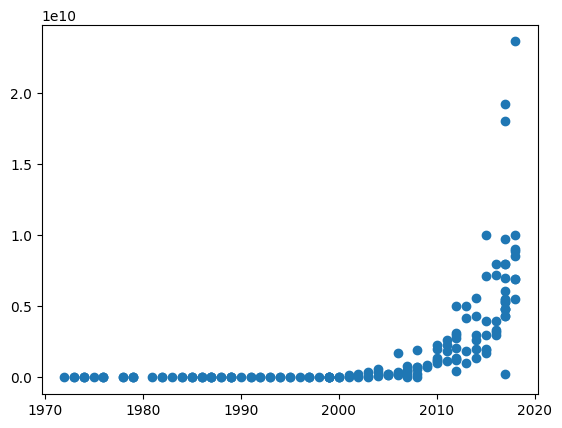

In [6]:
plt.scatter(X,y)

indeed moore law say the plot should be exponential, however if we take log it will be linear

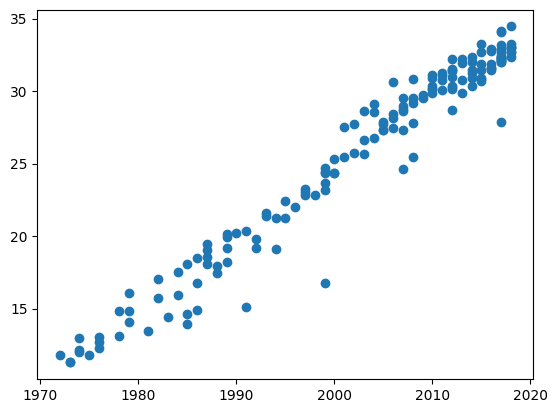

In [7]:
plt.scatter(X,np.log2(y))

now indeed a linear regression model can be used!

## transform the data

In [8]:
X = X.reshape(-1,1)
y = np.log2(y).reshape(-1,1)
print(f'X shape {X.shape} y shape {y.shape} ')
#normalize data
Xstd = X.std()
Xmean = X.mean()
ystd = y.std()
ymean= y.mean()

X= (X-Xmean)/Xstd
y = (y-ymean)/ystd

inputs = torch.from_numpy(X.astype(np.float32)).cuda()
targets = torch.from_numpy(y.astype(np.float32)).cuda()

X shape (161, 1) y shape (161, 1) 


## create the model

In [9]:
model = nn.Linear(X.shape[1],y.shape[1]).cuda()
criterion = nn.MSELoss().cuda()
optimizer = opt.SGD(model.parameters(),lr=0.01,momentum=0.7)



## training 

In [10]:
EPOCHS = 90
losses = []

for epoch in range(EPOCHS): 
    model.zero_grad()

    predictions = model(inputs)
    loss = criterion(predictions,targets)
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    print(f'{epoch+1}/{EPOCHS} loss: {loss.item()}')

1/90 loss: 2.4939627647399902
2/90 loss: 2.396764039993286
3/90 loss: 2.23789119720459
4/90 loss: 2.045104742050171
5/90 loss: 1.8386306762695312
6/90 loss: 1.6323351860046387
7/90 loss: 1.4351226091384888
8/90 loss: 1.252226710319519
9/90 loss: 1.0862841606140137
10/90 loss: 0.9381687641143799
11/90 loss: 0.8076123595237732
12/90 loss: 0.6936536431312561
13/90 loss: 0.594948947429657
14/90 loss: 0.509983479976654
15/90 loss: 0.43720847368240356
16/90 loss: 0.3751267194747925
17/90 loss: 0.3223414719104767
18/90 loss: 0.27758195996284485
19/90 loss: 0.23971228301525116
20/90 loss: 0.20773060619831085
21/90 loss: 0.18076248466968536
22/90 loss: 0.1580505222082138
23/90 loss: 0.13894294202327728
24/90 loss: 0.1228816956281662
25/90 loss: 0.10939081758260727
26/90 loss: 0.09806576371192932
27/90 loss: 0.08856357634067535
28/90 loss: 0.08059418946504593
29/90 loss: 0.07391267269849777
30/90 loss: 0.06831252574920654
31/90 loss: 0.06361986696720123
32/90 loss: 0.059688445180654526
33/90 los

## plot losses

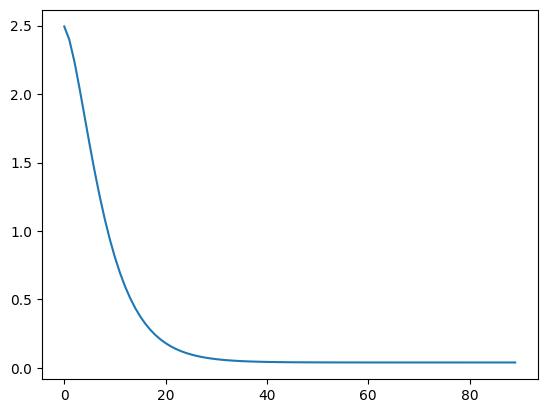

In [11]:
plt.plot(losses)

In [12]:
predictions =None
with torch.no_grad():
    predictions = model(inputs).cpu().numpy()

print(predictions)

[[-2.2101243 ]
 [-2.137388  ]
 [-2.137388  ]
 [-2.0646517 ]
 [-2.0646517 ]
 [-2.0646517 ]
 [-1.9919156 ]
 [-1.9191792 ]
 [-1.9191792 ]
 [-1.9191792 ]
 [-1.7737067 ]
 [-1.7737067 ]
 [-1.7009704 ]
 [-1.7009704 ]
 [-1.7009704 ]
 [-1.5554979 ]
 [-1.4827616 ]
 [-1.4827616 ]
 [-1.4100252 ]
 [-1.337289  ]
 [-1.337289  ]
 [-1.2645528 ]
 [-1.2645528 ]
 [-1.2645528 ]
 [-1.1918164 ]
 [-1.1918164 ]
 [-1.1918164 ]
 [-1.1190802 ]
 [-1.1190802 ]
 [-1.1190802 ]
 [-1.1190802 ]
 [-1.0463439 ]
 [-1.0463439 ]
 [-0.97360766]
 [-0.97360766]
 [-0.97360766]
 [-0.97360766]
 [-0.9008714 ]
 [-0.82813513]
 [-0.82813513]
 [-0.75539887]
 [-0.75539887]
 [-0.6826626 ]
 [-0.6826626 ]
 [-0.6099263 ]
 [-0.6099263 ]
 [-0.5371901 ]
 [-0.24624498]
 [-0.5371901 ]
 [-0.4644538 ]
 [-0.39171752]
 [-0.39171752]
 [-0.39171752]
 [-0.31898126]
 [-0.24624498]
 [-0.24624498]
 [-0.1735087 ]
 [-0.1735087 ]
 [-0.24624498]
 [-0.24624498]
 [-0.24624498]
 [-0.1735087 ]
 [-0.10077245]
 [-0.10077245]
 [-0.02803618]
 [ 0.11743636]
 [ 0.11743

let's revert the normalization

In [18]:
w = model.weight.detach().cpu().numpy()
b = model.bias.detach().cpu().numpy()

print(f'y={w}x+{b}')

y=[[0.9794617]]x+[0.00042584]


In [13]:
X = X*Xstd+Xmean
y = y*ystd+ymean
predictions = predictions*ystd+ymean

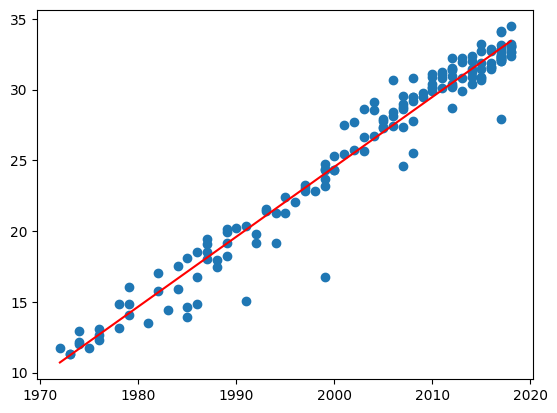

In [14]:
plt.scatter(X,y)
plt.plot(X,predictions,color='red')

[[2025]]


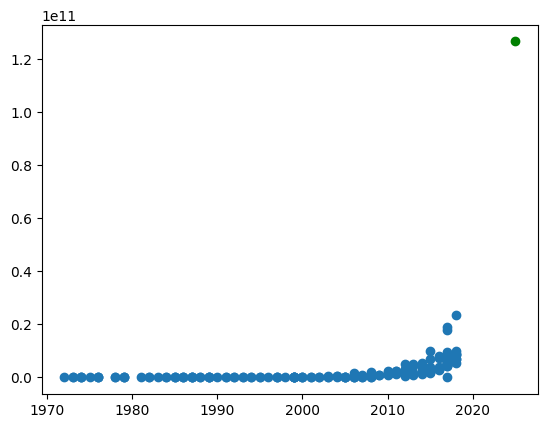

In [15]:
#single point prediction
a = np.asarray([2025])
a = a.reshape(-1,1)
print(a)
a = (a-Xmean) / Xstd
singleinput = torch.from_numpy(a.astype(np.float32)).cuda()
with torch.no_grad():
    out = model(singleinput).cpu().numpy()
    out = out*ystd+ymean
    a = a*Xstd + Xmean
    plt.scatter(X,np.exp2(y))
    plt.scatter(a,np.exp2(out),color='green')